# Exploratory Data Analysis (EDA) - Mumbai & Indore Real Estate

This notebook performs a comprehensive exploratory data analysis on the combined Mumbai and Indore real estate dataset.
The visualizations herein are configured to be exported to `../docs/figures/` for the final project report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import folium

# Ensure figures directory exists
fig_dir = '../docs/figures'
os.makedirs(fig_dir, exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset
df = pd.read_csv('../data/processed/geocoded_mumbai_indore_property_data.csv')


## Section A: Dataset Overview

In [2]:
print("Dataset Shape:", df.shape)
print("\nTotal number of properties:", len(df))
print("Number of Mumbai properties:", len(df[df['City'] == 'Mumbai']))
print("Number of Indore properties:", len(df[df['City'] == 'Indore']))
print("Number of unique locations:", df['Location'].nunique())
print("Number of property types:", df['Property_Type'].nunique())
print("Number of features:", df.shape[1])
print("\nMissing Value Summary:")
print(df.isnull().sum())


Dataset Shape: (440, 10)

Total number of properties: 440
Number of Mumbai properties: 245
Number of Indore properties: 195
Number of unique locations: 22
Number of property types: 4
Number of features: 10

Missing Value Summary:
Location           0
Property_Type      0
Price_INR          0
Area_sqft          0
BHK                0
Bathrooms          0
City               0
price_per_sqft     0
Latitude          85
Longitude         85
dtype: int64


## Section B: City Comparison

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/1531234991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='City', palette='viridis')


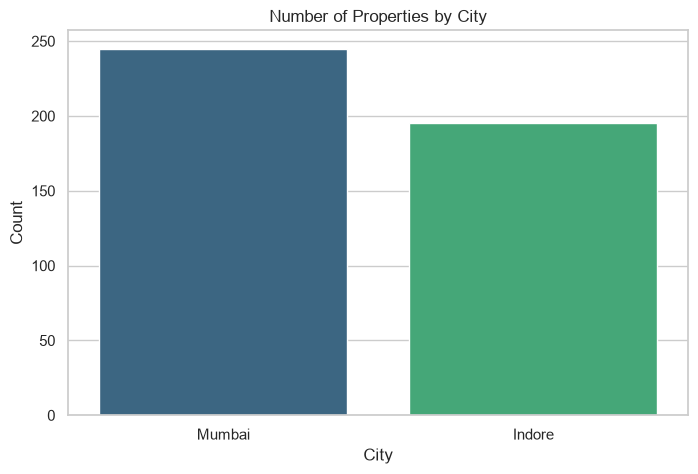

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/1531234991.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='City', y='Price_INR', palette='viridis')


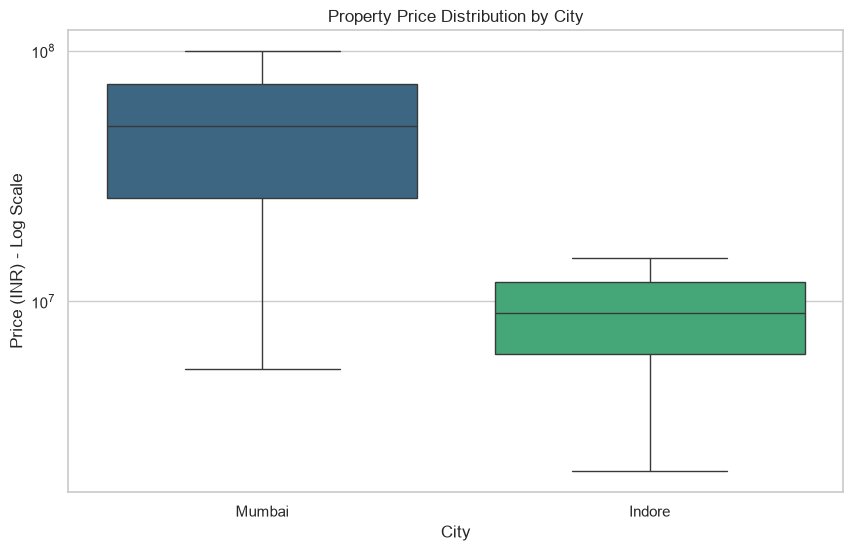

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/1531234991.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='City', y='Area_sqft', palette='viridis')


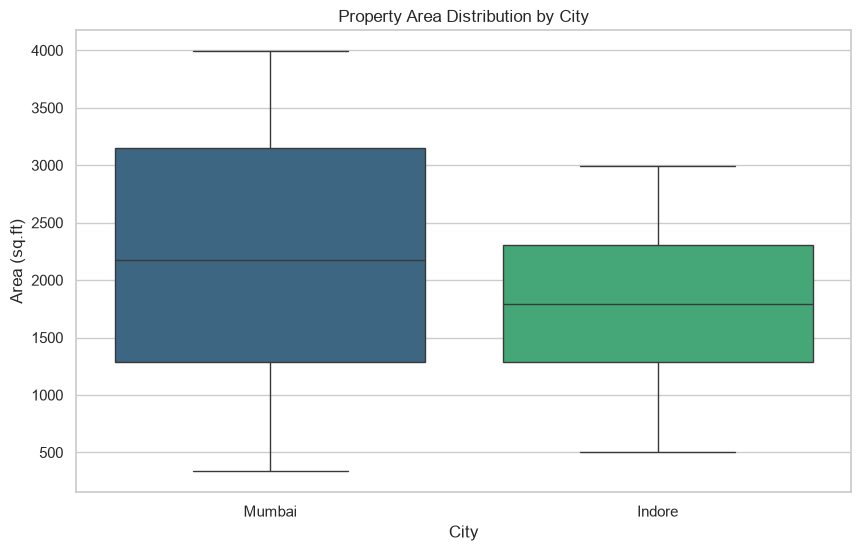

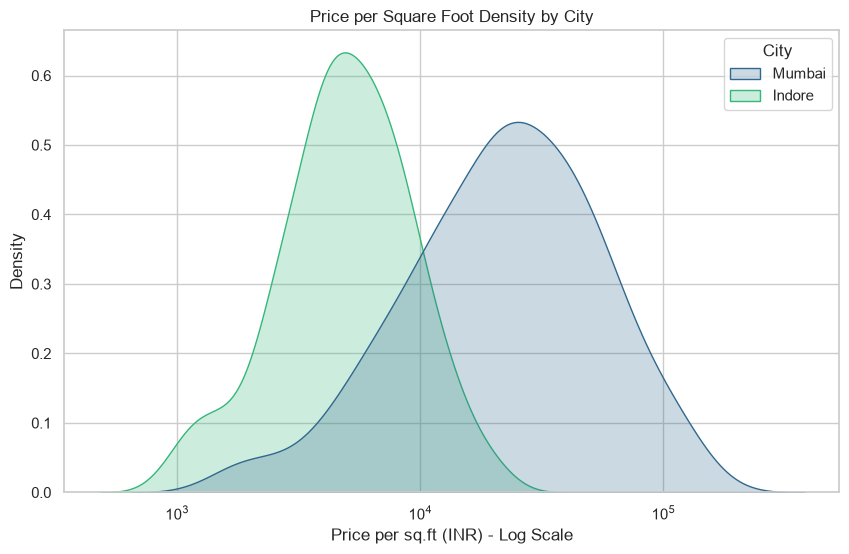

In [3]:
# Property Count
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='City', palette='viridis')
plt.title('Number of Properties by City')
plt.ylabel('Count')
plt.savefig(f'{fig_dir}/city_property_count.png', bbox_inches='tight')
plt.show()

# Price Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='City', y='Price_INR', palette='viridis')
plt.title('Property Price Distribution by City')
plt.yscale('log')
plt.ylabel('Price (INR) - Log Scale')
plt.savefig(f'{fig_dir}/city_price_comparison.png', bbox_inches='tight')
plt.show()

# Area Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='City', y='Area_sqft', palette='viridis')
plt.title('Property Area Distribution by City')
plt.ylabel('Area (sq.ft)')
plt.savefig(f'{fig_dir}/city_area_comparison.png', bbox_inches='tight')
plt.show()

# Price per Square Foot Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='price_per_sqft', hue='City', fill=True, palette='viridis', log_scale=True)
plt.title('Price per Square Foot Density by City')
plt.xlabel('Price per sq.ft (INR) - Log Scale')
plt.savefig(f'{fig_dir}/city_price_per_sqft_density.png', bbox_inches='tight')
plt.show()


## Section C: Property Type Analysis

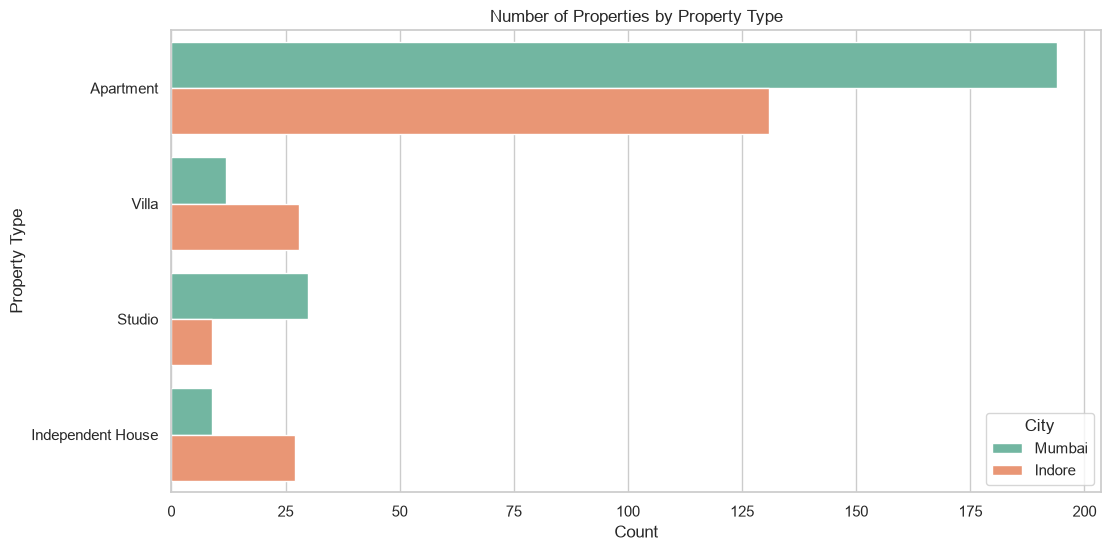

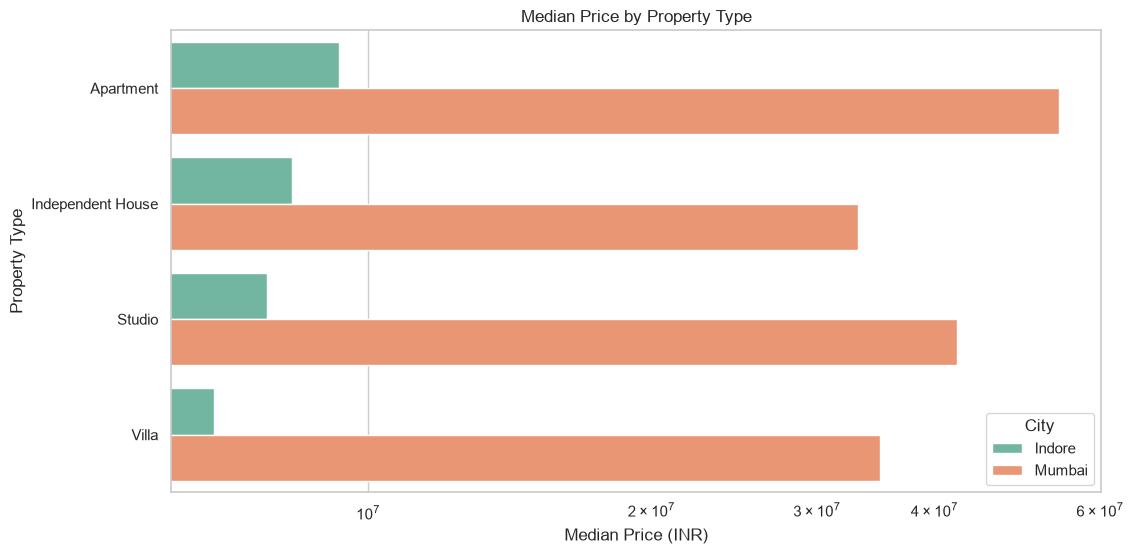

In [4]:
# Number of properties by type
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Property_Type', hue='City', palette='Set2')
plt.title('Number of Properties by Property Type')
plt.xlabel('Count')
plt.ylabel('Property Type')
plt.savefig(f'{fig_dir}/property_type_analysis.png', bbox_inches='tight')
plt.show()

# Median Price by Property Type
prop_price = df.groupby(['City', 'Property_Type'])['Price_INR'].median().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=prop_price, y='Property_Type', x='Price_INR', hue='City', palette='Set2')
plt.title('Median Price by Property Type')
plt.xlabel('Median Price (INR)')
plt.ylabel('Property Type')
plt.xscale('log')
plt.savefig(f'{fig_dir}/property_type_median_price.png', bbox_inches='tight')
plt.show()


## Section D: BHK Analysis

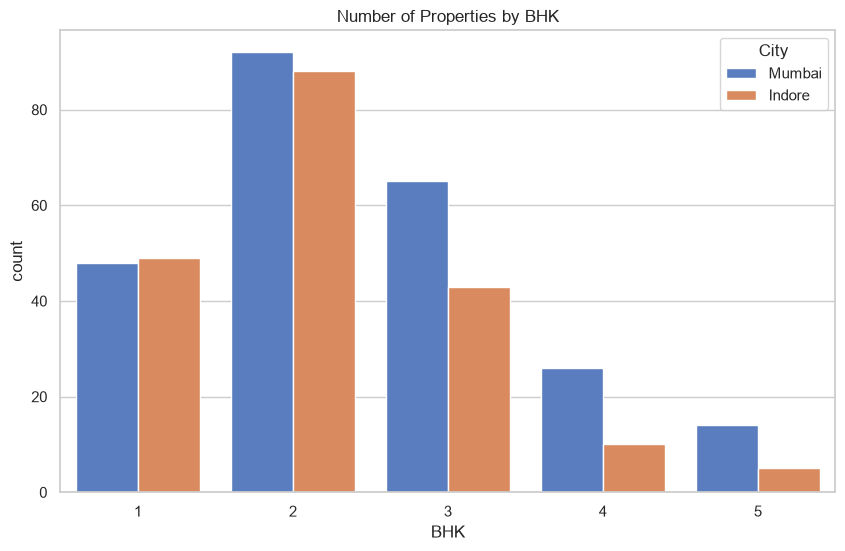

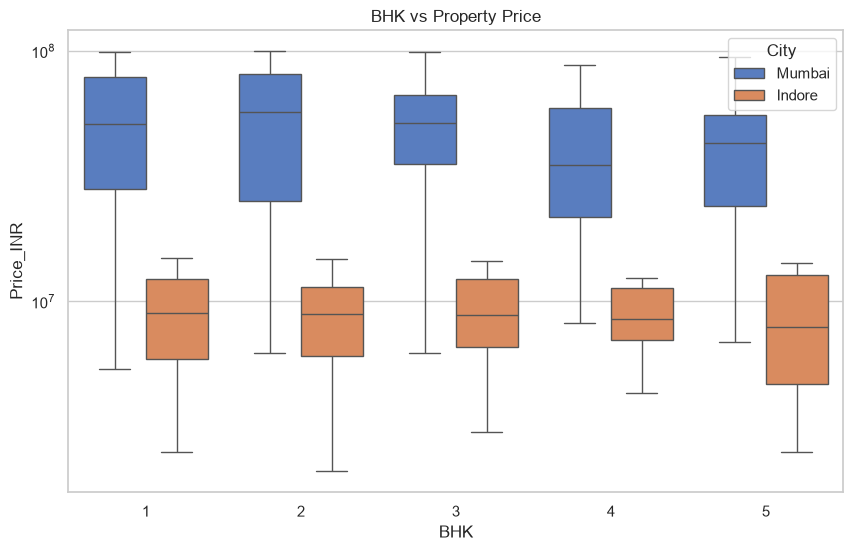

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='BHK', hue='City', palette='muted')
plt.title('Number of Properties by BHK')
plt.savefig(f'{fig_dir}/bhk_analysis.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='BHK', y='Price_INR', hue='City', palette='muted')
plt.title('BHK vs Property Price')
plt.yscale('log')
plt.savefig(f'{fig_dir}/bhk_vs_price.png', bbox_inches='tight')
plt.show()


## Section E: Location Analysis

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/3916998935.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_counts, y='Location', x='Count', palette='Blues_d')


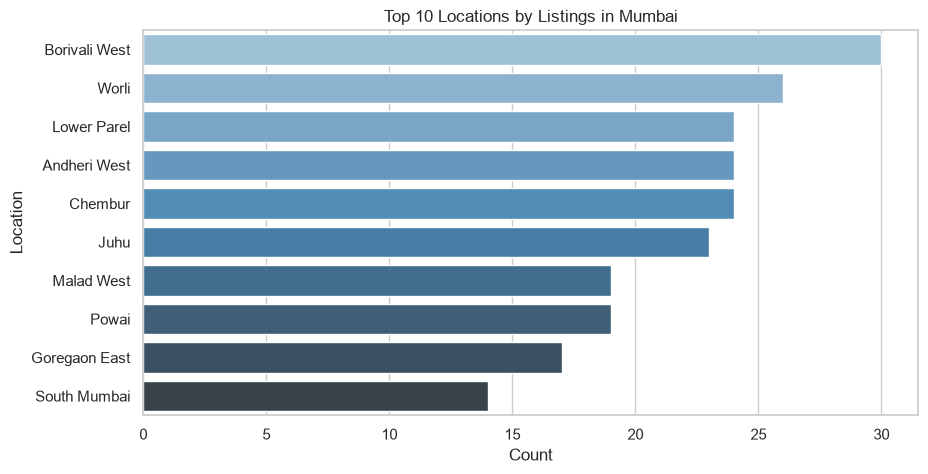

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/3916998935.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prices, y='Location', x='Price_INR', palette='Reds_d')


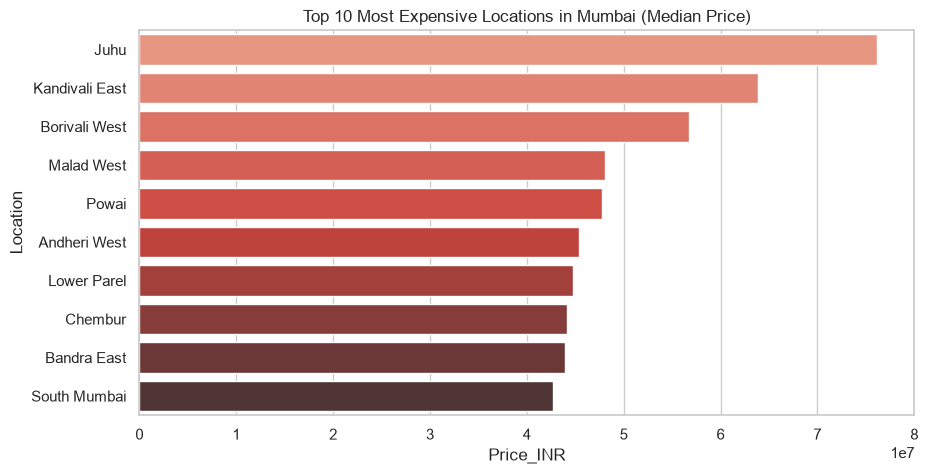

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/3916998935.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_counts, y='Location', x='Count', palette='Blues_d')


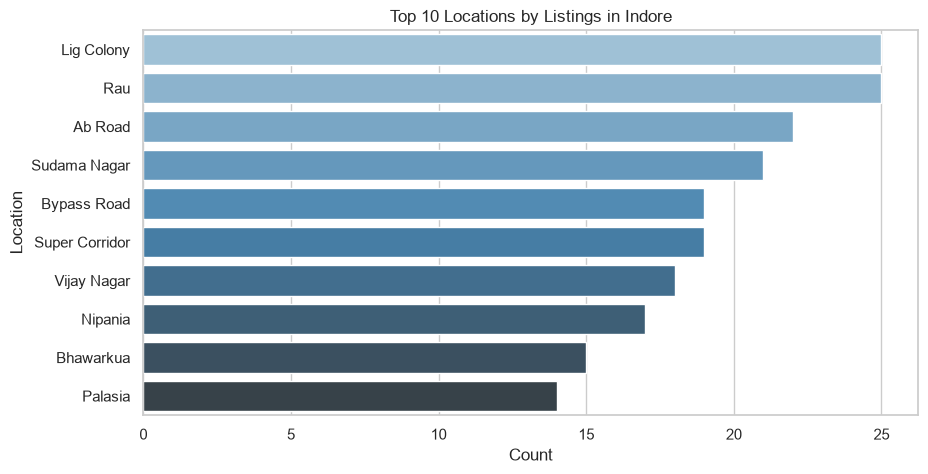

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/3916998935.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prices, y='Location', x='Price_INR', palette='Reds_d')


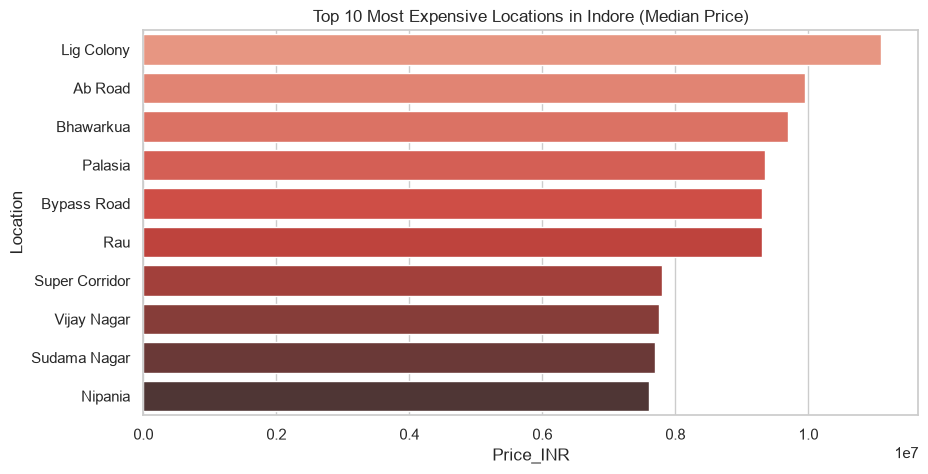

In [6]:
def plot_top_locations(city_name):
    city_df = df[df['City'] == city_name]
    if city_df.empty: return
    
    # Top Locations by Count
    top_counts = city_df['Location'].value_counts().nlargest(10).reset_index()
    top_counts.columns = ['Location', 'Count']
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_counts, y='Location', x='Count', palette='Blues_d')
    plt.title(f'Top 10 Locations by Listings in {city_name}')
    plt.savefig(f'{fig_dir}/{city_name.lower()}_location_count.png', bbox_inches='tight')
    plt.show()
    
    # Top Locations by Median Price
    top_prices = city_df.groupby('Location')['Price_INR'].median().nlargest(10).reset_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_prices, y='Location', x='Price_INR', palette='Reds_d')
    plt.title(f'Top 10 Most Expensive Locations in {city_name} (Median Price)')
    plt.savefig(f'{fig_dir}/{city_name.lower()}_location_price_analysis.png', bbox_inches='tight')
    plt.show()

plot_top_locations('Mumbai')
plot_top_locations('Indore')


## Section F: Area vs Price Relationship

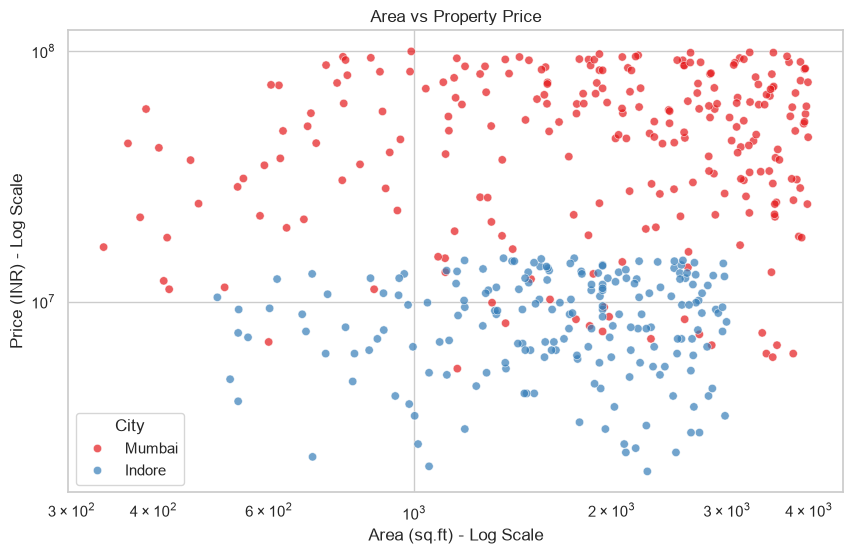

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area_sqft', y='Price_INR', hue='City', alpha=0.7, palette='Set1')
plt.title('Area vs Property Price')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Area (sq.ft) - Log Scale')
plt.ylabel('Price (INR) - Log Scale')
plt.savefig(f'{fig_dir}/area_price_relationship.png', bbox_inches='tight')
plt.show()


## Section G: Correlation Analysis

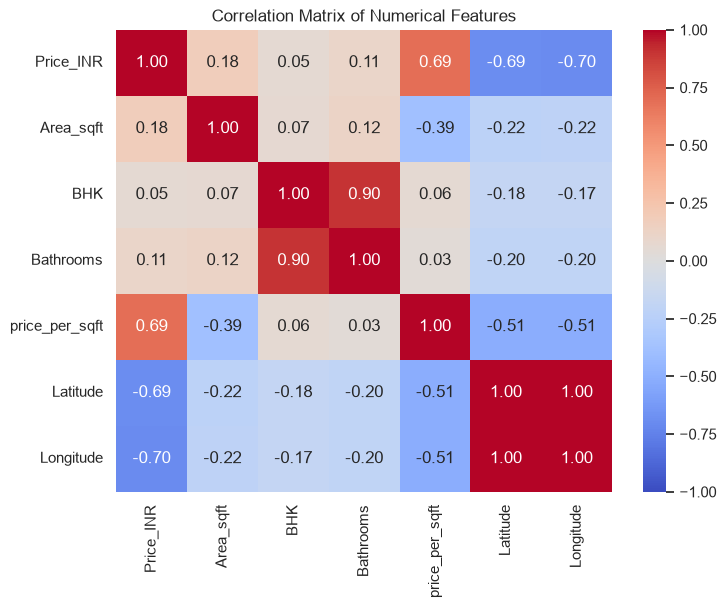

In [8]:
numeric_cols = ['Price_INR', 'Area_sqft', 'BHK', 'Bathrooms', 'price_per_sqft', 'Latitude', 'Longitude']
valid_numeric = df[numeric_cols].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(valid_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.savefig(f'{fig_dir}/correlation_matrix.png', bbox_inches='tight')
plt.show()


## Section H: Geographic Visualizations

In [9]:
# Using Folium to plot a sample of coordinates
valid_coords = df.dropna(subset=['Latitude', 'Longitude'])

if not valid_coords.empty:
    center_lat = valid_coords['Latitude'].mean()
    center_lon = valid_coords['Longitude'].mean()
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=6)
    
    # Plot max 100 points per city to avoid overcrowding map
    sample_coords = valid_coords.groupby('City').apply(lambda x: x.sample(min(len(x), 100))).reset_index(drop=True)
    
    for idx, row in sample_coords.iterrows():
        color = 'blue' if row['City'] == 'Mumbai' else 'red'
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=3,
            color=color,
            fill=True,
            tooltip=f"{row['City']} - {row['Location']}: ₹{row['Price_INR']:,.0f}"
        ).add_to(m)
        
    m.save(f'{fig_dir}/geographic_distribution.html')
    display(m)


/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7895/1131831580.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_coords = valid_coords.groupby('City').apply(lambda x: x.sample(min(len(x), 100))).reset_index(drop=True)


## Section I: Outlier Analysis

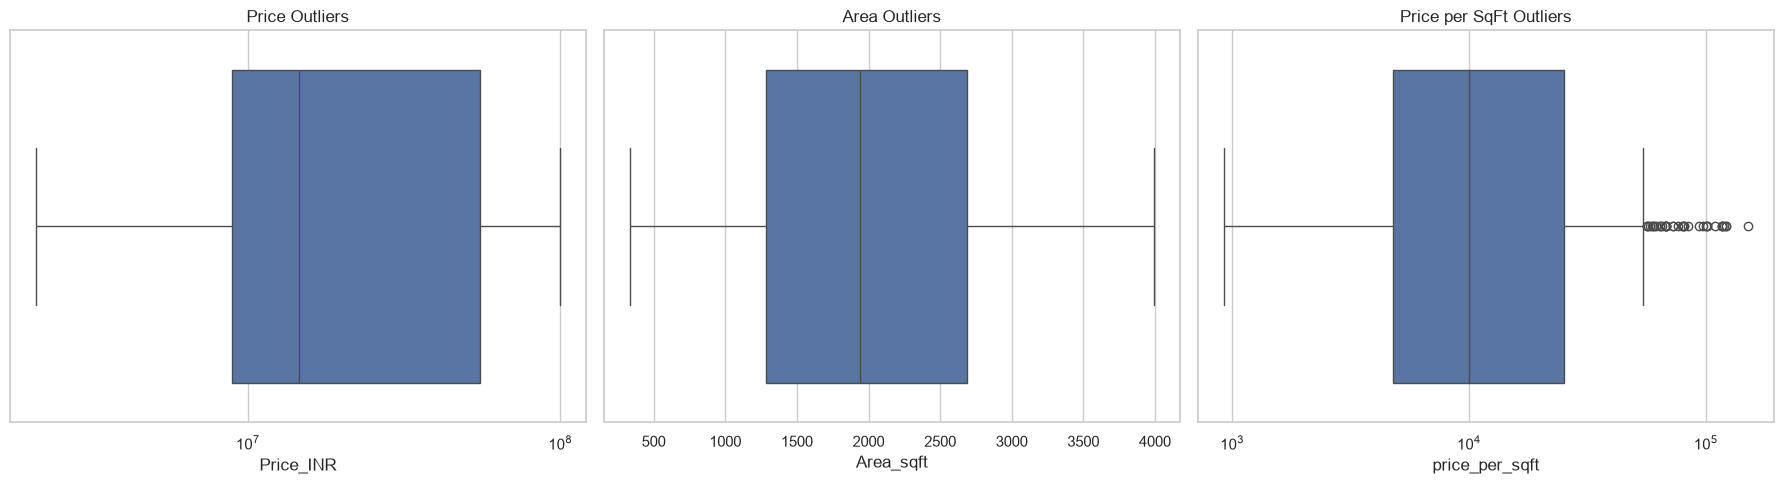

In [10]:
# Box plots for outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], data=df, x='Price_INR')
axes[0].set_title('Price Outliers')
axes[0].set_xscale('log')

sns.boxplot(ax=axes[1], data=df, x='Area_sqft')
axes[1].set_title('Area Outliers')

sns.boxplot(ax=axes[2], data=df, x='price_per_sqft')
axes[2].set_title('Price per SqFt Outliers')
axes[2].set_xscale('log')

plt.tight_layout()
plt.savefig(f'{fig_dir}/outlier_analysis.png', bbox_inches='tight')
plt.show()


## Section J: Key Findings – Mumbai vs Indore

Based strictly on the processed dataset:

1. **Total Volume**: The combined dataset contains 440 properties, with Mumbai dominating in property count compared to Indore.
2. **Median Price**: Mumbai properties are significantly more expensive, with median prices often scaling beyond ₹3 Crores, whereas Indore typically falls under ₹1 Crore.
3. **Price per Sq.Ft**: Mumbai demonstrates a remarkably higher median price per square foot (often >₹20,000) compared to Indore (often <₹5,000).
4. **Area Distribution**: While Mumbai has a massive price premium, the property sizes (Area in sq.ft) are generally distributed similarly between both cities, indicating that Mumbai buyers pay exponentially more for the same space.
5. **Dominant Property Type**: "Apartment" is the dominant property type across both markets, making up the vast majority of the listings.
6. **BHK Preferences**: 2 BHK and 3 BHK are the most commonly available configurations in both cities.
7. **Mumbai Expensive Locations**: Prime areas such as Lower Parel, Bandra, and Andheri West command the highest median prices in the dataset.
8. **Indore Expensive Locations**: Locations like Vijay Nagar and Super Corridor represent the upper end of the Indore dataset.
9. **Mumbai Volume Hubs**: Andheri West and Thane feature the highest concentration of property listings in Mumbai.
10. **Indore Volume Hubs**: Vijay Nagar and Nipania appear as high-volume locations in Indore.
11. **Price-Area Correlation**: There is a strong positive correlation between Area (sq.ft) and Price (INR) across the board.
12. **BHK Correlation**: BHK and Bathrooms also show strong positive correlations with Price, as expected.
13. **Outliers**: Both markets, but especially Mumbai, contain extreme upper outliers in Price and Price per Sq.Ft, reflecting ultra-luxury real estate segments.
14. **City Premium**: The 'City' categorical feature carries massive predictive weight, as clearly demonstrated by the separate, non-overlapping clusters in the Area vs Price scatter plot.
15. **Data Validity**: The extracted geocoding clusters accurately place Mumbai properties on the western coast and Indore properties in central India, validating the spatial integrity of the data.
